In [8]:
import os
import re
import json
import random
import nltk
# nltk.download('punkt_tab')
from openai import OpenAI
from dotenv import load_dotenv
from datasets import load_dataset, utils

In [49]:
texts_pool_dir = "seed_texts_pool"
os.makedirs(texts_pool_dir, exist_ok=True)
seed_texts_data_path = os.path.join(texts_pool_dir, "seed_texts_data.json")

# Browse CC-News titles

In [10]:
ds = load_dataset("vblagoje/cc_news")

print(ds.column_names)

{'train': ['title', 'text', 'domain', 'date', 'description', 'url', 'image_url']}


In [11]:
# filter dataset to texts between 150 and 250 words
len_filtered_ds = ds.filter(lambda x: 150 <= len(x['text']) < 250)['train']

print(len_filtered_ds.num_rows)

31319


In [34]:
# sample articles from different domains, print the titles, dates, and domains to check fitness for survey

utils.disable_progress_bar()

# sample 20 articles
# sample_articles = len_filtered_ds.shuffle().select(range(20))
sample_articles = len_filtered_ds.filter(lambda x: 'reuters' in x['domain'])

# print the sampled articles' titles, dates, and domains
for i, article in enumerate(sample_articles):
    article_date = article['date'][:10] + " " * (10 - len(article['date'][:10]))
    article_domain = article['domain'] + " " * (30 - len(article['domain']))
    print(f"{article_date} | {article_domain} | {article['title']}")

2017-04-29 | uk.reuters.com                 | Soccer-Finnish championship results and standings
2017-04-20 | uk.reuters.com                 | BRIEF-Guocoland posts qtrly profit attributable of S$29.6 mln
2018-02-02 | uk.reuters.com                 | BRIEF-Dolphin Entertainment Files For Mixed Shelf Of Upto $30 Mln
2017-03-31 | uk.reuters.com                 | BRIEF-Cheniere Energy Partners announces substantial completion of train 3 of Sabine Pass Liquefaction Project
2017-04-13 | uk.reuters.com                 | BRIEF-Basic Energy Services files for mixed shelf offering of up to $1 bln
2017-03-30 | uk.reuters.com                 | BRIEF-ELECOM completes acquisition, owning 96 pct stake in DX Antenna
2017-04-13 | uk.reuters.com                 | BRIEF-Saudi's Taiba Holding board proposes Q1 cash dividend
2017-04-10 | uk.reuters.com                 | UPDATE 1-Soccer-Argentine championship results and standings
2017-04-10 | uk.reuters.com                 | Soccer-Finnish championship res

In [40]:
# selected article titles
titles = [
    "Why are companies moving to the cloud? 81% simply fear 'missing out'",
    "Inside the Beijing Dance Academy",
    "Why Wikipedia's cofounder wants to replace the online encyclopedia with the blockchain",
    "Uber Investigation Leads to Shake-Up",
    "Why Americans Go Crazy Over the Super Bowl",
    "Weird and wonderful Christmas traditions across Europe",
    "This Day in WMMO History - May 30th",
    "Egypt's parliament approves Red Sea islands transfer to Saudi Arabia",
    "How much do you know about the Solar Eclipse?",
    "A look at the physical tests needed to be a firefighter",
    "The Indigenous Revival of Traditional Birth",
    "Former First Lady Barbara Bush has died at 92",
    "Quantum physicist named Australian of the Year",
    "Scientists Discover 91 Volcanoes Below Antarctic Ice Sheet",
    "History of the century old Congressional baseball game",
    "Ireland's safe haven at sea",
    "Tree-planting drones hope to fight deforestation",
    "Russia's society: Why so many oligarchs?",
    "Nobel Peace Prize goes to anti-nuclear group",
    "The mystery of disappearing Chinese tycoons",
    "Newly Discovered Prehistoric Worm Creature 'Strange Beyond Measure'"
]

len(titles)

21

# Generate texts

In [ ]:
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

client = OpenAI(api_key=api_key)

def generate_text(title):  
    model = "gpt-5.2-chat-latest"
    prompt = f"Write a 200-word news article titled: {title}. Output only the article text, without the title or any other information."
    response = client.responses.create(model=model,input=prompt)  
    output_text = response.output_text.strip()
    return output_text

In [31]:
# generate text for each title, store in a list, and save in text files

# find latest index of existing text files in the texts pool directory to avoid overwriting
existing_files = [f for f in os.listdir(texts_pool_dir) if f.endswith(".txt")]
existing_indices = [int(re.match(r"(\d+)_", f).group(1)) for f in existing_files if re.match(r"(\d+)_", f)]
start_index = max(existing_indices) + 1 if existing_indices else 1

output_texts = []
for i, title in enumerate(titles[-1:], start=start_index):
    text = generate_text(title)
    output_texts.append(text)
    with open(os.path.join(texts_pool_dir, f"{i:02d}_{title}.txt"), "w") as f:
        f.write(text)

In [46]:
output_texts = []
for file in sorted(os.listdir(texts_pool_dir)):
    if file.endswith(".txt"):
        with open(os.path.join(texts_pool_dir, file), "r") as f:
            text = f.read()
            output_texts.append(text)

len(output_texts)

21

# Get data on generated texts

In [43]:
# tokenizer for splitting text into sentences (for sentence-by-sentence display in survey)
tokenizer = nltk.data.load('tokenizers/punkt/english.pickle')

In [50]:
data = {}

# from each generated text, extract list of sentences and sentences that are at the end of paragraphs 
for i, text in enumerate(output_texts):
    # split into sentences, paragraph per paragraph (to avoid issues with tokenization)
    # store end-of-paragraph sentences (those followed by 2 newline characters) in a list for later use in survey display
    sentences = []
    end_of_paragraph_sentences_indices = []
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    for p in paragraphs:
        sentences.extend(tokenizer.tokenize(p))
        end_of_paragraph_sentences_indices.append(len(sentences) - 1)  # store index of last sentence in the paragraph, 0-based

    data[i+1] = {
        "title": titles[i],
        "text": text,
        "sentence_list": sentences,
        "end_of_paragraph_sentences_indices": end_of_paragraph_sentences_indices, # 0-based
    }

# save the data as a json file for later use in survey display
# use utf-8 encoding to preserve special characters, and ensure_ascii=False to avoid escaping non-ASCII characters
with open(os.path.join(seed_texts_data_path), encoding="utf-8", mode="w") as f:
    json.dump(data, f, indent=4, ensure_ascii=False) 

## Descriptive stats of generated seed texts 

### Sentence length

In [51]:
sentence_counts = [len(entry["sentence_list"]) for entry in data.values()]
print(sentence_counts)

[10, 12, 9, 10, 13, 9, 8, 11, 12, 10, 11, 12, 8, 9, 10, 8, 10, 13, 9, 10, 9]


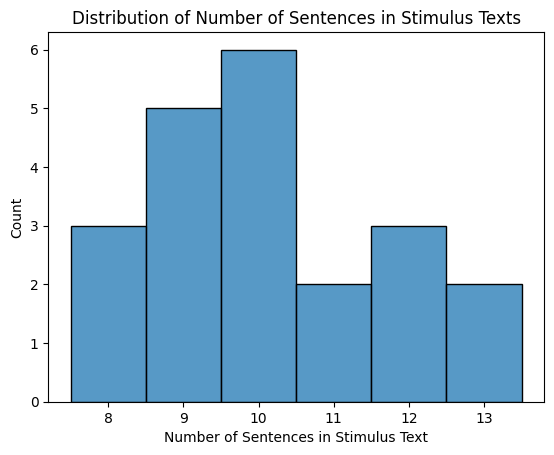

In [52]:
# plot histogram of number of sentences per stimulus text to check variability in text lengths
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    sentence_counts, discrete=True,
    ).set(
    title="Distribution of Number of Sentences in Stimulus Texts", 
    xlabel="Number of Sentences in Stimulus Text", 
    ylabel="Count")
plt.show()

In [53]:
# descriptive statistics of sentence counts
import numpy as np 
print(f"Mean number of sentences: {np.mean(sentence_counts):.2f}")
print(f"Median number of sentences: {np.median(sentence_counts)}")
print(f"Min number of sentences: {np.min(sentence_counts)}")
print(f"Max number of sentences: {np.max(sentence_counts)}")

# find outliers in terms of number of sentences (using 1.5*IQR rule)
q1 = np.percentile(sentence_counts, 25)
q3 = np.percentile(sentence_counts, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
# print outliers and with their sentence lengths and titles
outliers = [(count, i+1) for i, count in enumerate(sentence_counts) if count < lower_bound or count > upper_bound]
print("Outlier(s) in sentence length (sentence count, title):")
for count, id in outliers:
    print(f"  [{count} sentences] (ID={id}) {title}")

Mean number of sentences: 10.14
Median number of sentences: 10.0
Min number of sentences: 8
Max number of sentences: 13
Outlier(s) in sentence length (sentence count, title):
